In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


## Cau 1

In [2]:
age1 = [13,15,16,16,19,20,20,21,22,22,25,25,25,25,30,33,33,35,35,35,35,36,40,45,46,52,70]

mean1 = np.mean(age1)
median1 = np.median(age1)
mode1 = stats.mode(age1, keepdims=True)
midrange1 = (min(age1) + max(age1)) / 2
q1_1, q3_1 = np.percentile(age1, [25, 75], method="midpoint")
var1 = np.var(age1)
std1 = np.std(age1)

print("mean =", mean1)
print("median =", median1)
print("mode =", mode1.mode, "count =", mode1.count)
print("midrange =", midrange1)
print("Q1 =", q1_1, " Q3 =", q3_1)
print("five-number summary:", min(age1), q1_1, median1, q3_1, max(age1))
print("variance =", var1, " std =", std1)


mean = 29.962962962962962
median = 25.0
mode = [25] count = [4]
midrange = 41.5
Q1 = 20.5  Q3 = 35.0
five-number summary: 13 20.5 25.0 35.0 70
variance = 161.29492455418384  std = 12.700193878606099


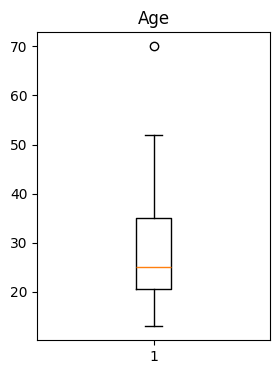

In [3]:
plt.figure(figsize=(3,4))
plt.boxplot(age1)
plt.title("Age")
plt.show()


## Cau 2

In [4]:
age2 = [23,23,27,27,39,41,47,49,50,52,54,54,56,57,58,58,60,61]
fat2 = [9.5,26.5,7.8,17.8,31.4,25.9,27.4,27.2,31.2,34.6,42.5,28.8,33.4,30.2,34.1,32.9,41.2,35.7]

df2 = pd.DataFrame({"age": age2, "fat": fat2})
df2.agg(["mean", "median", "var", "std"])


,age,fat
mean,46.444444,28.783333
median,51.000000,30.700000
var,174.732026,85.643824
std,13.218624,9.254395


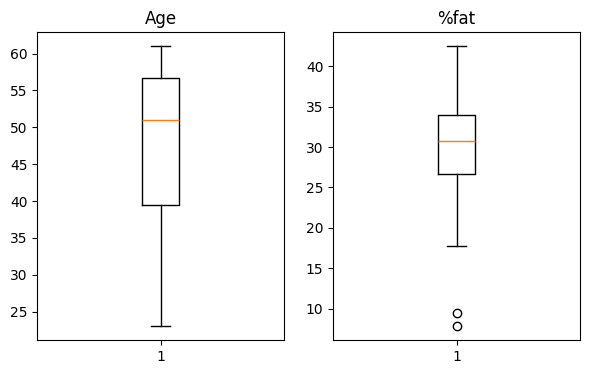

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7,4))
axes[0].boxplot(df2["age"]); axes[0].set_title("Age")
axes[1].boxplot(df2["fat"]); axes[1].set_title("%fat")
plt.show()


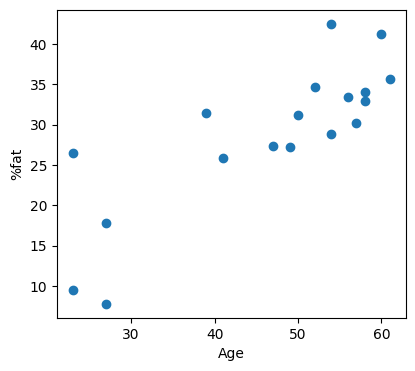

In [6]:
plt.figure(figsize=(4.5,4))
plt.scatter(df2["age"], df2["fat"])
plt.xlabel("Age"); plt.ylabel("%fat")
plt.show()


In [7]:
r, _ = stats.pearsonr(df2["age"], df2["fat"])
rho, _ = stats.spearmanr(df2["age"], df2["fat"])
print("Pearson r =", r)
print("Spearman rho =", rho)


Pearson r = 0.8176187964565874
Spearman rho = 0.806620132673992


## Cau 3

In [8]:
apps    = [5,7,6,11,11,12, 6,12,10,12,11,12,12,13,13, 9,8,6, 7]
goals   = [0,0,0,3,8,4,   7,6,10,12,17,10,16,12,15,  6,4,4,  6]
assists = [1,2,0,5,1,3,   1,4,3,1,5,4,4,6,3,          2,1,2,  0]

df3 = pd.DataFrame({"apps": apps, "goals": goals, "assists": assists})
df3.agg(["mean", "median", "var", "std"])


,apps,goals,assists
mean,9.631579,7.368421,2.526316
median,11.000000,6.000000,2.000000
var,7.467836,28.023392,3.152047
std,2.732734,5.293712,1.775400


In [9]:
df3.mode().iloc[0]


apps       12.0
goals       0.0
assists     1.0
Name: 0, dtype: float64

In [10]:
df3.quantile([0.25, 0.75], interpolation="midpoint")


,apps,goals,assists
0.25,7.0,4.0,1.0
0.75,12.0,11.0,4.0


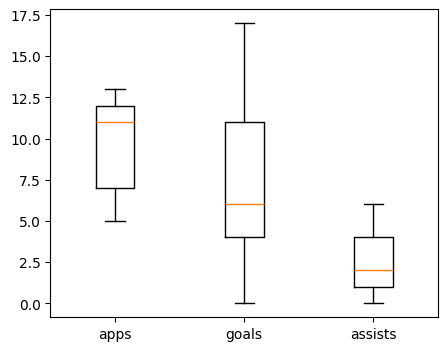

In [11]:
plt.figure(figsize=(5,4))
plt.boxplot([df3["apps"], df3["goals"], df3["assists"]],
            tick_labels=["apps","goals","assists"])
plt.show()


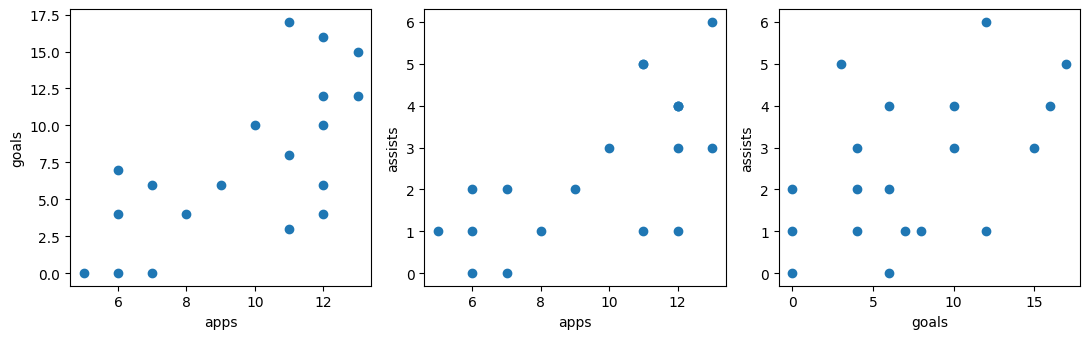

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11,3.5))
axes[0].scatter(df3["apps"], df3["goals"]); axes[0].set_xlabel("apps"); axes[0].set_ylabel("goals")
axes[1].scatter(df3["apps"], df3["assists"]); axes[1].set_xlabel("apps"); axes[1].set_ylabel("assists")
axes[2].scatter(df3["goals"], df3["assists"]); axes[2].set_xlabel("goals"); axes[2].set_ylabel("assists")
plt.tight_layout()
plt.show()


In [13]:
df3.cov(ddof=0)


,apps,goals,assists
apps,7.074792,9.504155,3.193906
goals,9.504155,26.548476,4.437673
assists,3.193906,4.437673,2.986150


## Cau 4

In [14]:
observed = pd.DataFrame(
    {"thich": [130, 35, 280], "khong_thich": [100, 165, 90]},
    index=["toan", "lich_su", "cntt"]
)
observed


,thich,khong_thich
toan,130,100
lich_su,35,165
cntt,280,90


In [15]:
chi2, p, dof, expected = stats.chi2_contingency(observed, correction=False)

print("expected:")
print(pd.DataFrame(expected, index=observed.index, columns=observed.columns).round(2))
print()
print("chi2 =", chi2, " dof =", dof, " p-value =", p)


expected:
          thich  khong_thich
toan     127.94       102.06
lich_su  111.25        88.75
cntt     205.81       164.19

chi2 = 178.1098133713091  dof = 2  p-value = 2.108363261691115e-39
